In [ ]:
from ultralytics import YOLO
import onnx
import onnxruntime as ort
from onnxruntime.quantization import quantize_dynamic, quantize_static, CalibrationDataReader, QuantType

import numpy as np
from PIL import Image
from matplotlib import pyplot as plt

import torch

import os

import cv2

# Create Onnx

In [2]:
# model = YOLO("piece_yolo.pt")
model = YOLO(os.path.join(os.environ["WEIGHTS"], "piece_yolo.pt"))
model_bd = YOLO(os.path.join(os.environ["WEIGHTS"], "bd_yolo.pt"))

In [4]:
model.export(format="onnx",
             opset=13,
             simplify=True,
             dynamic=True,
            #  half=True,
            #  device=0
            )

model_bd.export(format="onnx",
             opset=13,
             simplify=True,
             dynamic=True,
            #  half=True,
            #  device=0
            )

Ultralytics 8.3.201 🚀 Python-3.13.3 torch-2.7.1+cu126 CPU (Intel Core(TM) i7-9750H 2.60GHz)
Model summary (fused): 72 layers, 3,007,988 parameters, 0 gradients, 8.1 GFLOPs

PyTorch: starting from '/mnt/D/University/Thesis_Dataset/weights/piece_yolo.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 16, 8400) (6.0 MB)

ONNX: starting export with onnx 1.19.1 opset 13...
ONNX: slimming with onnxslim 0.1.71...
ONNX: export success ✅ 4.3s, saved as '/mnt/D/University/Thesis_Dataset/weights/piece_yolo.onnx' (12.2 MB)

Export complete (4.8s)
Results saved to /mnt/D/University/Thesis_Dataset/weights
Predict:         yolo predict task=detect model=/mnt/D/University/Thesis_Dataset/weights/piece_yolo.onnx imgsz=640  
Validate:        yolo val task=detect model=/mnt/D/University/Thesis_Dataset/weights/piece_yolo.onnx imgsz=640 data=/content/drive/MyDrive/Thesis se7s Fall2025/SuperTrainPrep/data.yaml  
Visualize:       https://netron.app
Ultralytics 8.3.201 🚀 Python-3.13.3 torch-2.7

'/mnt/D/University/Thesis_Dataset/weights/bd_yolo.onnx'

# Running Models

In [3]:
img = Image.open("/mnt/D/University/Thesis_Dataset/Dataset/Images/image_27.jpg").resize((640,640))
x = np.array(img).transpose(2,0,1)[None, :, :, :] / 255
x = x.astype(np.float32)

results = model(img)
# results = model(torch.flip(ds[0][0], (0,)).unsqueeze(0))
results[0].show()

/mnt/D/University/Thesis/.venv/lib/python3.13/site-packages/torch/cuda/__init__.py:174: UserWarning: CUDA initialization: CUDA unknown error - this may be due to an incorrectly set up environment, e.g. changing env variable CUDA_VISIBLE_DEVICES after program start. Setting the available devices to be zero. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:109.)
  return torch._C._cuda_getDeviceCount() > 0


0: 640x640 2 black-bishops, 1 black-king, 5 black-pawns, 2 black-rooks, 1 white-bishop, 2 white-kings, 4 white-pawns, 2 white-rooks, 110.2ms
Speed: 14.0ms preprocess, 110.2ms inference, 14.1ms postprocess per image at shape (1, 3, 640, 640)


In [6]:
session = ort.InferenceSession(
    "piece_yolo.onnx",
    providers=["CPUExecutionProvider"],
    # providers=["CUDAExecutionProvider"]

    # "piece_yolo_quantized_dynamic.onnx",
    # "piece_yolo_quantized_static.onnx",
    # providers=["OpenVINOExecutionProvider"]
)

outputs = session.run(None, {"images": x})
print(len(outputs), [o.shape for o in outputs])

1 [(1, 16, 8400)]


In [5]:
session_bd = ort.InferenceSession(
    os.path.join(os.environ["WEIGHTS"], "bd_yolo.onnx")
)

outputs_bd = session_bd.run(None, {"images": x})
print(len(outputs_bd), [o.shape for o in outputs_bd])

2 [(1, 37, 8400), (1, 32, 160, 160)]


# Viewing Onnx Results

In [11]:
# 0: 'black-bishop',
#  1: 'black-king',
#  2: 'black-knight',
#  3: 'black-pawn',
#  4: 'black-queen',
#  5: 'black-rook',
#  6: 'white-bishop',
#  7: 'white-king',
#  8: 'white-knight',
#  9: 'white-pawn',
#  10: 'white-queen',
#  11: 'white-rook

In [12]:
res = outputs[0][0]

confidence_threshold = 0.5
nms_threshold = 0.45

# OpenCV's NMS
indices = cv2.dnn.NMSBoxes(
    bboxes=res[:4].T.tolist(),  # Convert to list of [x, y, w, h] or keep [x1, y1, x2, y2]
    scores=res[4:].max(axis=0).tolist(),
    score_threshold=confidence_threshold,
    nms_threshold=nms_threshold
)

print(indices)

# Get filtered results
if len(indices) > 0:
    res = res[:,indices.flatten()]

[1458 1172 6569  996  921 4418 3637 2222 2757 6693  777 6775 6613 6582 2275 3579 2858 3619 6817]


In [13]:
cx = res[0]
cy = res[1]
w = res[2]
h = res[3]

x1 = cx - w / 2
y1 = cy - h / 2
x2 = cx + w / 2
y2 = cy + h / 2

corners = np.stack([
    x1,y1,x2,y2
], axis=1)

corners = np.stack([np.array([
    [row[0], row[1]],
    [row[2], row[1]],
    [row[2], row[3]],
    [row[0], row[3]],
]) for row in corners])

corners.shape

(19, 4, 2)

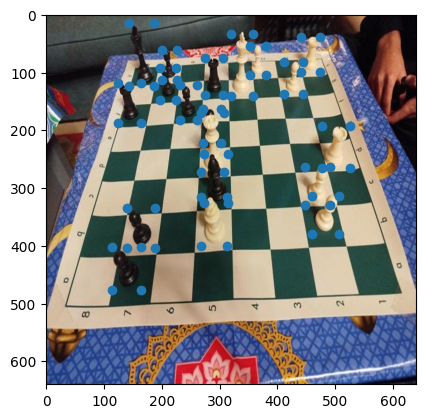

In [14]:
viewed_corners = corners
# viewed_corners = corners[res[4:].argmax(axis=0) == 3]
viewed_corners = viewed_corners.reshape(-1,2)

plt.imshow(img);
results = plt.scatter(viewed_corners[:,0], viewed_corners[:,1]);

In [31]:
def postprocess_yolo_segmentation(
    output_detection: np.ndarray, 
    output_proto: np.ndarray, 
    original_img_shape: tuple, 
    conf_threshold: float = 0.75,
    iou_threshold: float = 0.45,
) -> list:
    """
    Processes the raw ONNX outputs of a YOLO segmentation model to generate masks.

    Args:
        output_detection: The detection output (1, 37, 8400).
        output_proto: The prototype mask output (1, 32, 160, 160).
        original_img_shape: (H, W) of the original image before model input resizing.
        conf_threshold: Minimum confidence score to keep a detection.
        iou_threshold: NMS IoU threshold.

    Returns:
        A list of dictionaries, each containing 'box' (xyxy) and 'mask' (binary mask).
    """
    H, W = original_img_shape
    
    # --- 1. Filter and Prepare Detections (output_detection) ---
    
    # Transpose from (1, 37, 8400) to (8400, 37) and remove batch dimension
    predictions = np.squeeze(output_detection).T
    
    # 37 columns: [bbox(4), score(1), mask_coeffs(32)] 
    
    # Since you have 1 class, the class score is implicitly included in the 
    # score column (usually column 4, or index 4) in the simplified ONNX export.
    # The confidence score is typically the result of (Objectness * Class_Score).
    
    scores = predictions[:, 4]  # Objectness/Confidence Score
    
    # Filter by confidence threshold
    # valid_predictions = predictions
    # valid_scores = scores
    valid_predictions = predictions[scores > conf_threshold]
    valid_scores = scores[scores > conf_threshold]

    if len(valid_predictions) == 0:
        return []
    
    # Extract Bounding Boxes (xywh)
    boxes_xywh = valid_predictions[:, :4]
    
    # Convert boxes from xywh to xyxy (for NMS)
    boxes_xyxy = np.copy(boxes_xywh)
    boxes_xyxy[:, 0] -= boxes_xyxy[:, 2] / 2  # x1 = x - w/2
    boxes_xyxy[:, 1] -= boxes_xyxy[:, 3] / 2  # y1 = y - h/2
    boxes_xyxy[:, 2] = boxes_xyxy[:, 0] + boxes_xywh[:, 2]  # x2 = x1 + w
    boxes_xyxy[:, 3] = boxes_xyxy[:, 1] + boxes_xywh[:, 3]  # y2 = y1 + h

    # Rescale boxes to original image size (assuming 640x640 input to ONNX model)
    model_size = output_proto.shape[-1] * 4 # e.g., 160*4 = 640
    ratio_w, ratio_h = W / model_size, H / model_size
    boxes_xyxy[:, 0] *= ratio_w
    boxes_xyxy[:, 1] *= ratio_h
    boxes_xyxy[:, 2] *= ratio_w
    boxes_xyxy[:, 3] *= ratio_h
    
    # --- 2. Apply Non-Maximum Suppression (NMS) ---
    
    # The `cv2.dnn.NMSBoxes` function expects scores as float32
    indices = cv2.dnn.NMSBoxes(
        boxes_xyxy.tolist(), 
        valid_scores.tolist(), 
        conf_threshold, 
        iou_threshold
    )
    
    if len(indices) == 0:
        return []

    # Filtered results
    indices = indices.flatten()
    final_boxes = boxes_xyxy[indices]
    final_coeffs = valid_predictions[indices, 5:37] # Mask coefficients (32 values)

    
    # --- 3. Generate Raw Masks (Matrix Multiplication) ---
    
    # Reshape prototypes from (1, 32, 160, 160) to (32, 160*160)
    proto = np.squeeze(output_proto)
    proto = proto.reshape(32, -1) # Shape (32, 25600)

    # Matrix multiplication: (N_detections, 32) @ (32, 160*160) -> (N_detections, 160*160)
    raw_masks = final_coeffs @ proto
    
    # Apply Sigmoid
    raw_masks = 1 / (1 + np.exp(-raw_masks))

    # Reshape back to (N_detections, 160, 160)
    masks_160x160 = raw_masks.reshape(-1, *output_proto.shape[-2:])
    
    # --- 4. Upsample and Binarize ---
    
    final_results = []
    
    for i in range(len(final_boxes)):
        box_xyxy = final_boxes[i].astype(int)
        mask_160 = masks_160x160[i]
        
        # Upsample mask to original image size
        # Interpolation needs to be linear for probability maps
        mask_full_res = cv2.resize(mask_160, (W, H), interpolation=cv2.INTER_LINEAR)
        
        # Binarize mask
        binary_mask = (mask_full_res > 0.5).astype(np.uint8)
        
        # --- 5. Crop Mask (Optional but standard for instance segmentation) ---
        
        # Use the bounding box to crop the mask for the final output
        x1, y1, x2, y2 = box_xyxy
        
        # Create an empty mask for cropping
        cropped_mask = np.zeros((H, W), dtype=np.uint8)
        
        # The relevant part of the mask is within the detected box coordinates (xyxy)
        # Note: We must clip the box coordinates to image boundaries (0 to W/H-1)
        x1 = max(0, x1)
        y1 = max(0, y1)
        x2 = min(W, x2)
        y2 = min(H, y2)
        
        cropped_mask[y1:y2, x1:x2] = binary_mask[y1:y2, x1:x2]

        final_results.append({
            'box': box_xyxy, # Bounding box [x1, y1, x2, y2]
            'mask': cropped_mask, # Binary mask (0 or 255)
        })
        
    return final_results

In [32]:
res = postprocess_yolo_segmentation(outputs_bd[0], outputs_bd[1], (640,640))

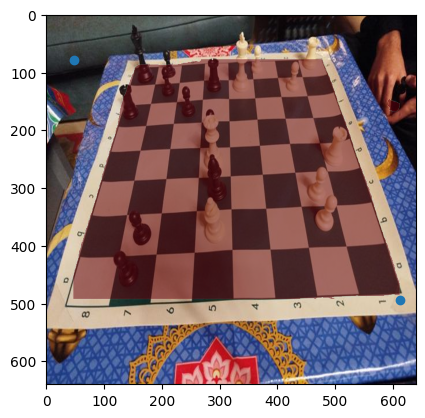

In [34]:
plt.imshow(img);
plt.imshow(res[0]["mask"], alpha=res[0]["mask"]*.5, cmap="Reds");

box = res[0]["box"]
plt.scatter([box[0],box[2]],[box[1],box[3]]);

In [25]:
res[0]["box"]

# res[0]["mask"].shape

array([ 47,  78, 612, 493])

# Testing Runtime

In [15]:
session.get_providers()

['CPUExecutionProvider']

In [16]:
%%timeit
outputs = session.run(None, {"images": x})

76.6 ms ± 1.36 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


# Optimize Onnx (Dynamic Quantization)

In [4]:
model_onnx = onnx.load("piece_yolo.onnx")
onnx.checker.check_model(model_onnx)

In [5]:
model_fp32 = "piece_yolo.onnx"
model_int8 = "piece_yolo_quantized_dynamic.onnx"

quantize_dynamic(
    model_input=model_fp32,
    model_output=model_int8,
    weight_type=QuantType.QUInt8,  # or QuantType.QUInt8
    # op_types_to_quantize=["MatMul", "Gemm"]
)

# Optimize Onnx (Static Quantization)

In [6]:
from Dataset.DataSetLoaders import ChessDataset
from PieceDetection.PieceCropper_3D import PieceCropper

In [7]:
ds = ChessDataset.ChessDataset(
    config={
        "img_size": (640,640)
    }
)

def prep(entry):
    img, lbl = entry
    return torch.flip(img, (0,)).unsqueeze(0)

class CalibrationDataReader(CalibrationDataReader):
    def __init__(self, input_name):
        self.input_name = input_name
        self.data_iter = iter([
            {input_name: prep(ds[_]).numpy()}
            for _ in range(10)
        ])

    def get_next(self):
        return next(self.data_iter, None)

In [8]:
# load model to find input name
model_fp32 = "piece_yolo.onnx"
session = ort.InferenceSession(model_fp32, providers=["CPUExecutionProvider"])
input_name = session.get_inputs()[0].name

dr = CalibrationDataReader(input_name)

quantize_static(
    model_input=model_fp32,
    model_output="piece_yolo_quantized_static.onnx",
    calibration_data_reader=dr,
    weight_type=QuantType.QInt16,
)
print("✅ Static quantization done")

✅ Static quantization done
